In [1]:
import torch 
from uni2ts.model.moirai import MoiraiForecast, MoiraiModule
from gluonts.dataset.common import ListDataset

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import skew, kurtosis
import yfinance as yf

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Portfolio Init

In [2]:
# Selected stock symbol
stock_symbol = "^N225"  # Nikkei 225 Index

# Stock Data Start and End Dates
end_date = pd.Timestamp("2026-09-01")
start_date = end_date - pd.DateOffset(years=2)

# start_date = pd.Timestamp("2020-01-01")

print(f"Fetching stock data from {start_date.date()} to {end_date.date()}")

Fetching stock data from 2024-09-01 to 2026-09-01


In [3]:
stockFetch = yf.download(stock_symbol, start=start_date, end=end_date)

[*********************100%***********************]  1 of 1 completed


In [ ]:
stockReturns = np.log1p(stockFetch['Close'].pct_change().dropna())

### Returns

<Axes: title={'center': '^N225 Stock Returns'}, xlabel='Date', ylabel='Log Returns'>

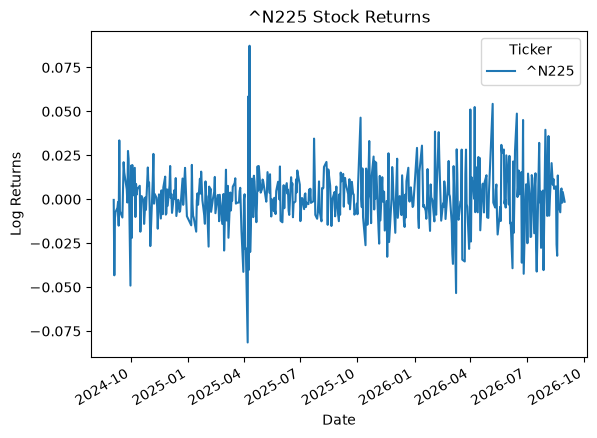

In [ ]:
stockReturns.plot(title=f"{stock_symbol} Stock Returns", ylabel="Log Returns", xlabel="Date")

## Foundation Model Prediction

In [ ]:
moirai_module = MoiraiModule.from_pretrained("Salesforce/moirai-1.0-R-base")

### Model Configs

In [8]:
predictionLength = 10
numSamples = 2000
batchSize = 4

In [9]:
moirai_model = MoiraiForecast(
    module=moirai_module,
    prediction_length=predictionLength, 
    target_dim=1, 
    feat_dynamic_real_dim=0,
    past_feat_dynamic_real_dim=0,
    context_length=len(stockReturns)
    )

In [10]:
stockReturnsTarget = stockReturns.squeeze().to_numpy(dtype=np.float32)

forecast_data = ListDataset(
    [
        {
            "start": pd.Timestamp(stockReturns.index[0]),
            "target": stockReturnsTarget,
        }
    ],
    freq="B",
)

/opt/homebrew/lib/python3.11/site-packages/gluonts/dataset/common.py:262: FutureWarning: Period with BDay freq is deprecated and will be removed in a future version. Use a DatetimeIndex with BDay freq instead.
  return pd.Period(val, freq)


In [11]:
predictor = moirai_model.create_predictor(batch_size=batchSize)
forecast = next(predictor.predict(forecast_data, num_samples=numSamples))

/opt/homebrew/lib/python3.11/site-packages/gluonts/transform/split.py:572: FutureWarning: Period with BDay freq is deprecated and will be removed in a future version. Use a DatetimeIndex with BDay freq instead.
  d[self.forecast_start_field] = d[self.start_field] + i + lt


### Cumulate each simulated return

In [12]:
def createCumulativeReturns(forecast):
    samples = forecast.samples
    cumulative_returns = np.cumsum(samples, axis=1)
    
    return cumulative_returns

def createCumulativeReturnsFromArray(forecast):
    samples = forecast
    cumulative_returns = np.cumsum(samples, axis=1)
    
    return cumulative_returns

In [13]:
def neutralizeUnrealisticReturns(returns, cap):
    mask = (returns > cap) | (returns < -cap)
    return np.where(mask, 0.0, returns)


#### Create a cap to avoid unrealistic values

In [14]:
cap = 100

filteredLogReturns = neutralizeUnrealisticReturns(forecast.samples, cap)
cappedCumulativeLogReturns = createCumulativeReturnsFromArray(filteredLogReturns)

### Transform to percentage return

In [15]:
cappedCumulativeReturns = np.expm1(cappedCumulativeLogReturns)

## Analyze model results

In [17]:
VaRQuantiles = [0.01, 0.025, 0.05, 0.075]
ESQuantiles = [0.025, 0.05, 0.075, 0.1]


varQuantileNames = [f"VaR_{q:0.1%}" for q in VaRQuantiles]
esQuantileNames = [f"ES_{q:0.1%}" for q in ESQuantiles]

In [18]:
def summarize_predictions(predictions):
    """Summarize log-return predictions across simulations for each forecast step."""
    values = np.asarray(predictions, dtype=float)

    # Treat a vector as one forecast step with multiple simulations.
    if values.ndim == 1:
        values = values[:, np.newaxis]
    if values.ndim != 2:
        raise ValueError("predictions must be a 1D vector or 2D matrix")

    measures = {
        "mean": np.mean(values, axis=0),
        "median": np.median(values, axis=0),
        "variance": np.var(values, axis=0),
        "min": np.min(values, axis=0),
        "max": np.max(values, axis=0),
        "skew": skew(values, axis=0),
        "kurtosis": kurtosis(values, axis=0),
    }

    for q, name in zip(VaRQuantiles, varQuantileNames):
        threshold = np.quantile(values, q, axis=0)
        measures[name] = threshold

    for q, name in zip(ESQuantiles, esQuantileNames):
        threshold = np.quantile(values, q, axis=0)
        measures[name] = np.array([
            values[values[:, step] <= threshold[step], step].mean()
            for step in range(values.shape[1])
        ])

    return measures

In [ ]:
summaryMeasures = summarize_predictions(cappedCumulativeReturns)

NameError: name 'cumulativeReturns' is not defined

### Visualize mean, median and variance

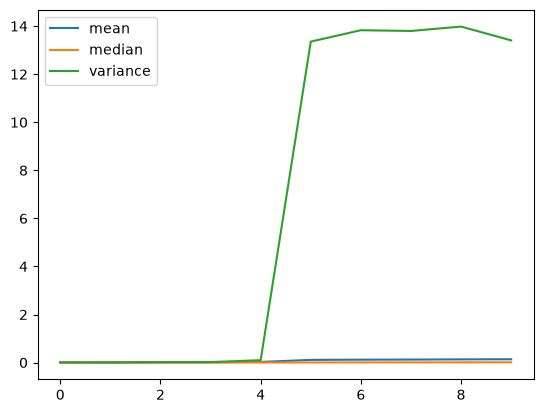

In [ ]:
curMeasures = ["mean", "median", "variance"]

for measure in curMeasures:
    plt.plot(plotIndex, summaryMeasures[measure], label=measure)

plt.legend()

### Correct measures by expected evolution (T)

In [ ]:
linearTimeEffect = (plotIndex+1) # forcing the first one to be 1 instead of an year fraction

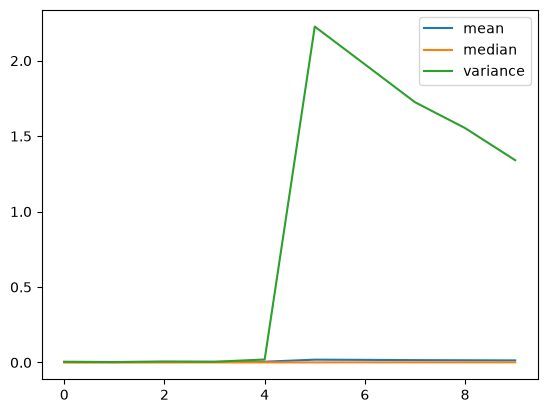

In [ ]:
curMeasures = ["mean", "median", "variance"]

for measure in curMeasures:
    correctedValues = summaryMeasures[measure]/linearTimeEffect
    plt.plot(plotIndex, correctedValues, label=measure)

plt.legend()

### Visualize skewness and kurtosis

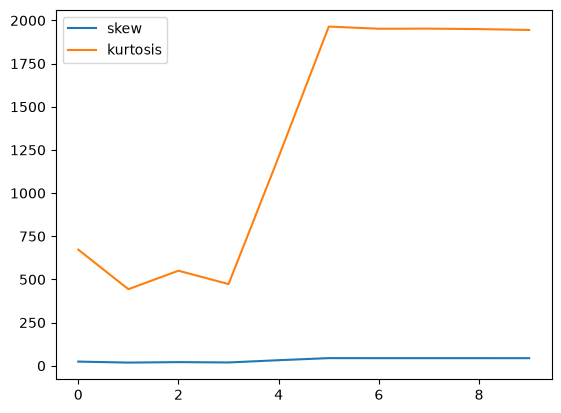

In [ ]:
curMeasures = ["skew", "kurtosis"]

for measure in curMeasures:
    correctedValues = summaryMeasures[measure]
    plt.plot(plotIndex, correctedValues, label=measure)

plt.legend()

## Visualize each quantile

### VaR

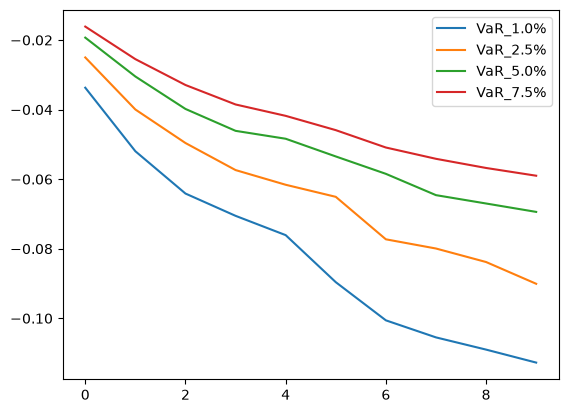

In [ ]:
for name in varQuantileNames:
    plt.plot(plotIndex, summaryMeasures[name], label=name)

plt.legend()

### VaR corrected by time

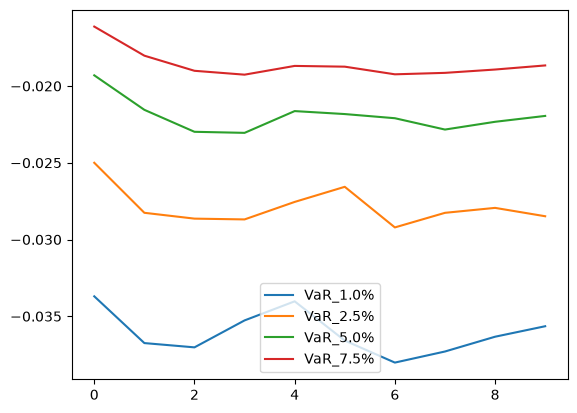

In [ ]:
for name in varQuantileNames:
    plt.plot(plotIndex, summaryMeasures[name]/np.sqrt(linearTimeEffect), label=name)

plt.legend()


### ESVaR

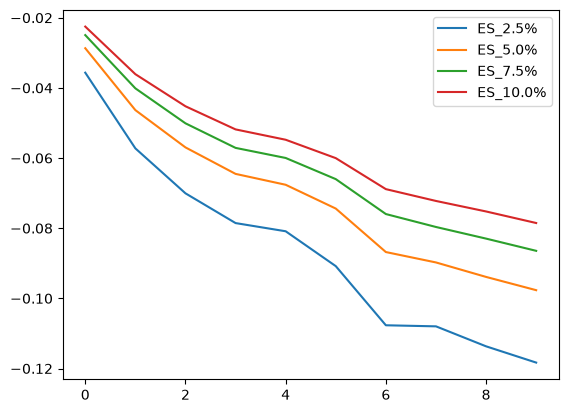

In [ ]:
for name in esQuantileNames:
    plt.plot(plotIndex, summaryMeasures[name], label=name)


plt.legend()

### ESVaR corrected by time

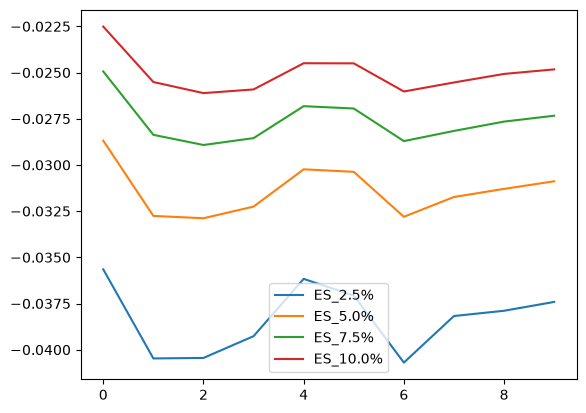

In [ ]:
for name in esQuantileNames:
    plt.plot(plotIndex, summaryMeasures[name]/np.sqrt(linearTimeEffect), label=name)

plt.legend()

## Estimate the impact of a shock on the last period return

In [ ]:
shockRange = [-0.5, -0.35, -0.2, -0.1, -0.05, -0.025, 0, 0.025, 0.05, 0.1, 0.2]
# shockRange = np.arange(-0.50, 0.50, 0.05).tolist()

print(f"Shock range: {shockRange}")

Shock range: [-0.5, -0.35, -0.2, -0.1, -0.05, -0.025, 0, 0.025, 0.05, 0.1, 0.2]


In [ ]:
lastShockedStockReturns = np.tile(stockReturnsTarget, (len(shockRange), 1))
lastShockedStockReturns[:, -1] = shockRange

In [ ]:
forecast_data_shocked = ListDataset(
    [
        {
            "start": pd.Timestamp(stockReturns.index[0]),
            "target": s,
        }
        for s in lastShockedStockReturns
    ],
    freq="B",
)

In [ ]:
shockForecasts = list(predictor.predict(forecast_data_shocked, num_samples=numSamples))

In [ ]:
cap = 100
def treatAndSummarizeForecasts(forecast):
    """Treat and summarize shock forecasts."""
    cappedReturns = neutralizeUnrealisticReturns(forecast.samples, cap)
    cumulativeLogReturns = createCumulativeReturnsFromArray(cappedReturns)
    cumulativeReturns = np.expm1(cumulativeLogReturns)
    return summarize_predictions(cumulativeReturns)


In [ ]:
shockSummaries = {shock: treatAndSummarizeForecasts(forecast) for shock,forecast in zip(shockRange, shockForecasts)}

/var/folders/wl/dsgcr5td4tx3c1sbxjc_50s80000gn/T/ipykernel_3693/3781739474.py:6: RuntimeWarning: overflow encountered in expm1
  cumulativeReturns = np.expm1(cumulativeLogReturns)
/opt/homebrew/lib/python3.11/site-packages/numpy/core/_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
/opt/homebrew/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1070: RuntimeWarning: invalid value encountered in subtract
  a_zero_mean = a - mean


### Check shock results

### One day ahead sensibility

In [ ]:
meanOneDay = [summary["mean"][0] for summary in shockSummaries.values()]
varianceOneDay = [summary["variance"][0] for summary in shockSummaries.values()]
kurtosisOneDay = [summary["kurtosis"][0] for summary in shockSummaries.values()]
skewnessOneDay = [summary["skew"][0] for summary in shockSummaries.values()]

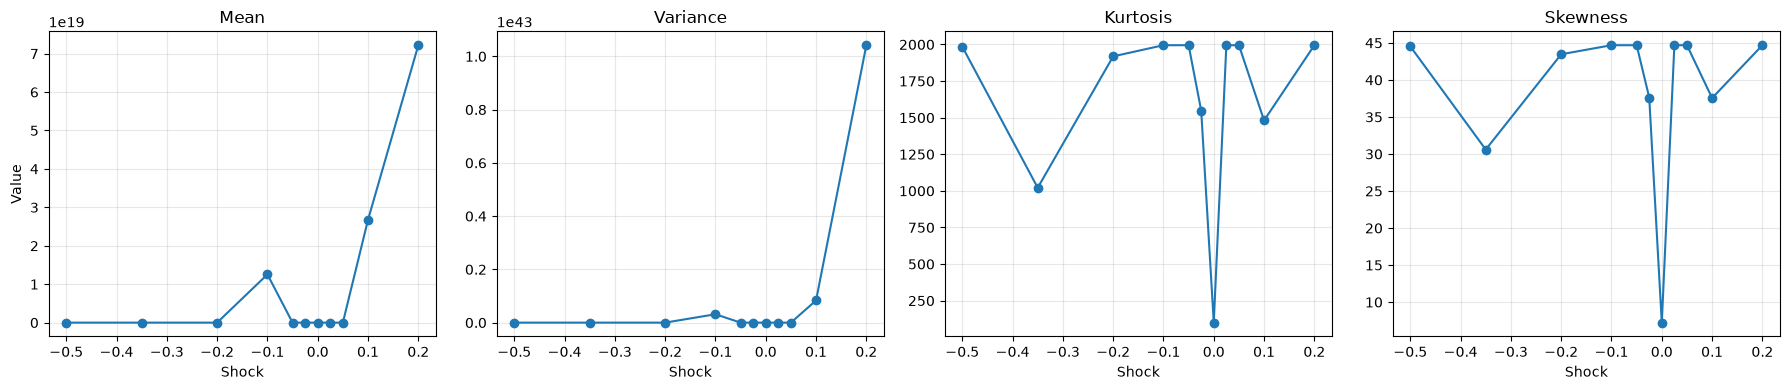

In [ ]:
metrics = [
    (meanOneDay, "Mean"),
    (varianceOneDay, "Variance"),
    (kurtosisOneDay, "Kurtosis"),
    (skewnessOneDay, "Skewness"),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharex=True)

for ax, (values, title) in zip(axes, metrics):
    ax.plot(shockRange, values, marker="o")
    ax.set_title(title)
    ax.set_xlabel("Shock")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Value")
fig.tight_layout()
plt.show()


In [ ]:
varsOneDay = {q: [summary[f"VaR_{q:0.1%}"][0] for summary in shockSummaries.values()] for q in VaRQuantiles}
esOneDay = {q: [summary[f"ES_{q:0.1%}"][0] for summary in shockSummaries.values()] for q in ESQuantiles}

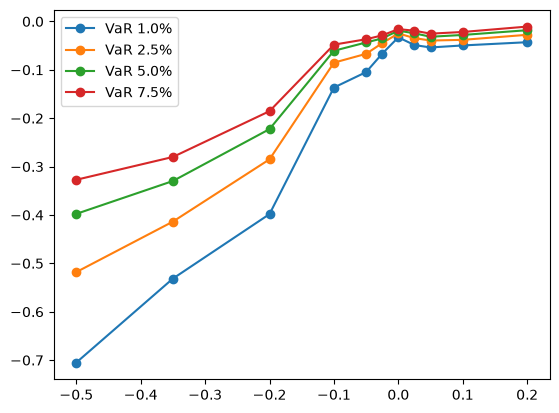

In [ ]:
for q, values in varsOneDay.items():
    plt.plot(shockRange, values, marker="o", label=f"VaR {q:0.1%}")

plt.legend()

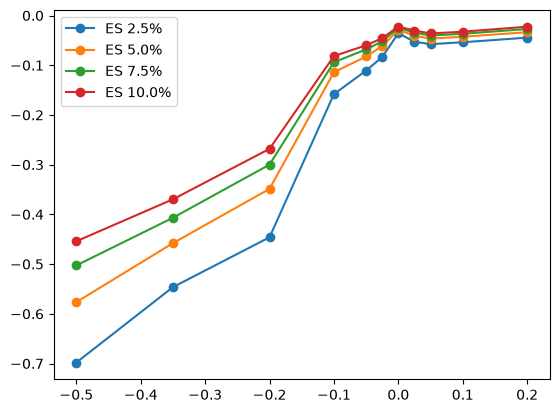

In [ ]:
for q, values in esOneDay.items():
    plt.plot(shockRange, values, marker="o", label=f"ES {q:0.1%}")

plt.legend()

### Mean over time with no time affect

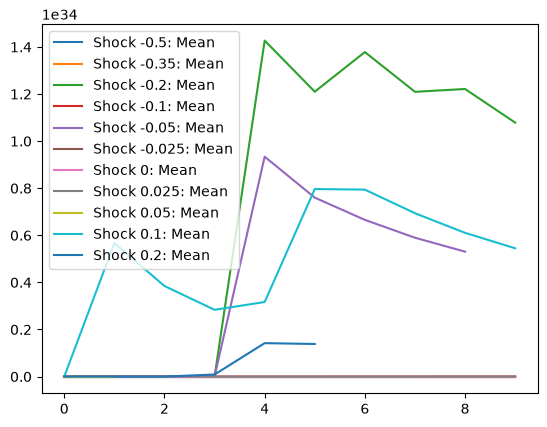

In [ ]:
for shock, summary in shockSummaries.items():
    plt.plot(plotIndex, summary["mean"]/linearTimeEffect, label=f"Shock {shock}: Mean")

plt.legend()

### Variance over time with no time affect

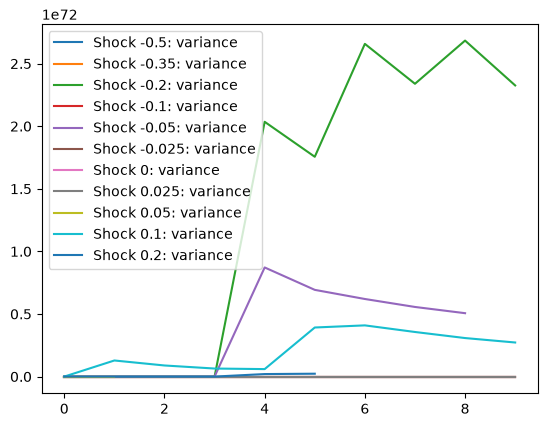

In [ ]:
for shock, summary in shockSummaries.items():
    plt.plot(plotIndex, summary["variance"]/linearTimeEffect, label=f"Shock {shock}: variance")

plt.legend()

### Kurtosis over time

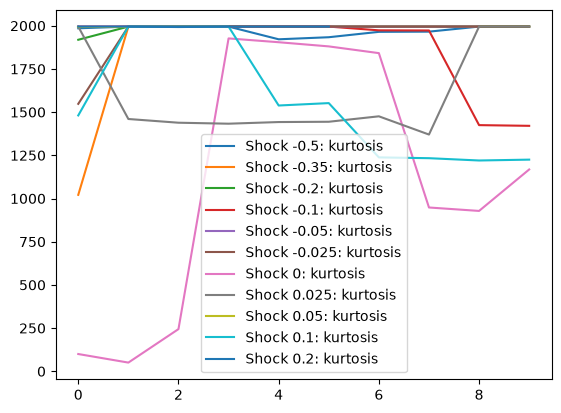

In [ ]:
for shock, summary in shockSummaries.items():
    plt.plot(plotIndex, summary["kurtosis"], label=f"Shock {shock}: kurtosis")

plt.legend()

### Skewness over time

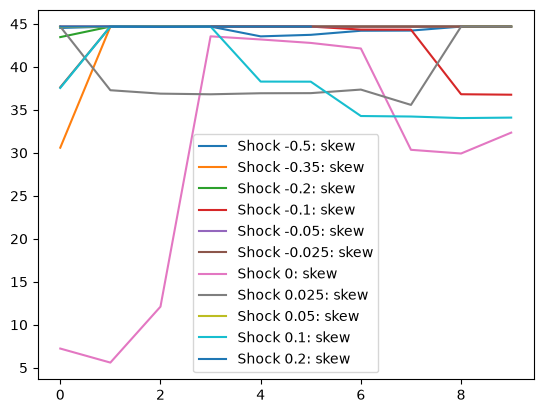

In [ ]:
for shock, summary in shockSummaries.items():
    plt.plot(plotIndex, summary["skew"], label=f"Shock {shock}: skew")

plt.legend()

### VaR 5% over time

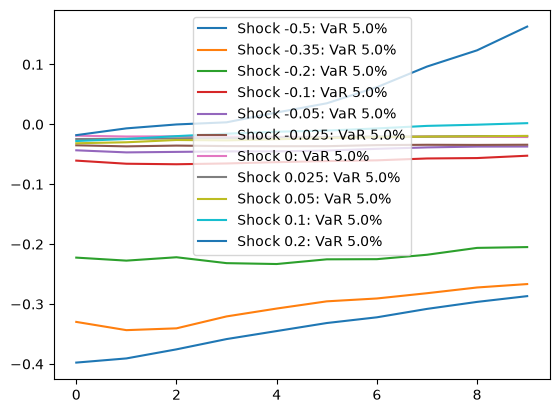

In [ ]:
for shock, summary in shockSummaries.items():
    plt.plot(plotIndex, summary["VaR_5.0%"]/np.sqrt(linearTimeEffect), label=f"Shock {shock}: VaR 5.0%")

plt.legend()

### ESVaR 5% over time

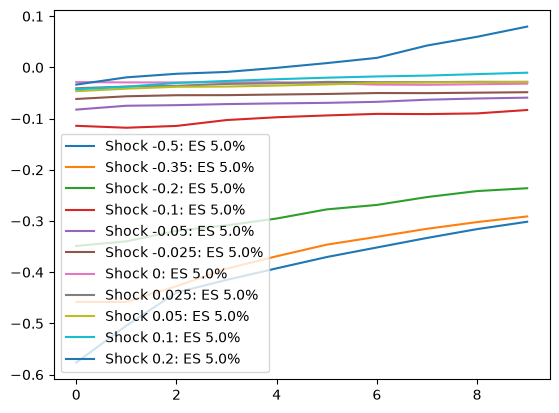

In [ ]:
for shock, summary in shockSummaries.items():
    plt.plot(plotIndex, summary["ES_5.0%"]/np.sqrt(linearTimeEffect), label=f"Shock {shock}: ES 5.0%")
    

plt.legend()